##Definición del problema de negocio

Las empresas con apps móviles o servicios digitales pierden usuarios de forma silenciosa: el cliente deja de usar el servicio sin dar aviso previo. Este fenómeno, conocido como churn, genera pérdida de ingresos recurrentes y aumenta el costo de adquisición de clientes al tener que reponer constantemente la base activa.

**Objetivo de Análisis:**
Identificar y comprender los factores demográficos, de cuenta y de servicios que mayor impacto tienen en la cancelación del servicio (Churn) por parte de los clientes de la empresa de telecomunicaciones, con el fin de generar un panorama que permitan diseñar estrategias de retención efectivas.

**Hipótesis:**
Los clientes con contratos de corto plazo (Mes a mes) presentan una tasa de cancelación significativamente mayor que aquellos con contratos a largo plazo (1 o 2 años).

Los clientes que no cuentan con servicios de valor agregado, como Soporte Técnico o Seguridad en línea, son más propensos a abandonar la empresa.

Existe una correlación positiva entre el aumento de los Cargos Mensuales y la probabilidad de cancelación (Churn).

###Pregunta analítica

¿Qué usuarios tienen mayor probabilidad de abandonar el servicio en los próximos 30 días, y cuáles deben priorizarse en campañas de re-engagement?

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd

# Usamos la URL normal de la página del dataset (sin la parte de /api/v1/...)
url = "https://www.kaggle.com/datasets/blastchar/telco-customer-churn"

# Iniciamos la descarga (te pedirá usuario y key de kaggle)
od.download(url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: MemoLeon74
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


100%|██████████| 172k/172k [00:00<00:00, 53.4MB/s]

In [ ]:
df = pd.read_csv('/content/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.info() # Diccionario de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


se puede identificar que el dataframe consta de 7043 filas y 21 columnas.

De las 21 columna, 2 son de tipo int, 1 de tipo float, 'con las cuales se puede realizar analisis matematicos y estadisticos', las otras son de tipo object, para otro tipo de analisis.

el dataframe tiene un peso de 1.1 MB.

In [ ]:
# Renombrar columnas a español
df.rename(columns={
    'customerID'       : 'id_cliente',
    'gender'           : 'genero',
    'SeniorCitizen'    : 'adulto_mayor',      # 0 = No, 1 = Sí
    'Partner'          : 'tiene_pareja',
    'Dependents'       : 'tiene_dependientes',
    'tenure'           : 'meses_permanencia',
    'PhoneService'     : 'servicio_telefono',
    'MultipleLines'    : 'lineas_multiples',
    'InternetService'  : 'tipo_internet',
    'OnlineSecurity'   : 'seguridad_online',
    'OnlineBackup'     : 'respaldo_online',
    'DeviceProtection' : 'proteccion_dispositivo',
    'TechSupport'      : 'soporte_tecnico',
    'StreamingTV'      : 'transmicion_tv',
    'StreamingMovies'  : 'transmicion_peliculas',
    'Contract'         : 'tipo_contrato',
    'PaperlessBilling' : 'factura_digital',
    'PaymentMethod'    : 'metodo_pago',
    'MonthlyCharges'   : 'cargo_mensual',
    'TotalCharges'     : 'cargo_total',
    'Churn'            : 'churn'      # variable objetivo (1=churn, 0=no churn)
}, inplace=True)

# ── Verificar ──────────────────────────────────────────────────────
print("Columnas renombradas:")
print(df.columns.tolist())

Columnas renombradas:
['id_cliente', 'genero', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes', 'meses_permanencia', 'servicio_telefono', 'lineas_multiples', 'tipo_internet', 'seguridad_online', 'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico', 'transmicion_tv', 'transmicion_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago', 'cargo_mensual', 'cargo_total', 'churn']


In [ ]:
# cargo_total tiene espacios vacíos que impiden convertirla a float
df['cargo_total'] = pd.to_numeric(df['cargo_total'], errors='coerce')

# Verificar cuántos nulos quedaron tras la conversión
print(f"Nulos en cargo_total: {df['cargo_total'].isnull().sum()}")

# Son solo 11 filas — se pueden imputar con la mediana
df['cargo_total'] = df['cargo_total'].fillna(df['cargo_total'].median())

# Confirmar tipos finales
print(df.dtypes)

Nulos en cargo_total: 11
id_cliente                 object
genero                     object
adulto_mayor                int64
tiene_pareja               object
tiene_dependientes         object
meses_permanencia           int64
servicio_telefono          object
lineas_multiples           object
tipo_internet              object
seguridad_online           object
respaldo_online            object
proteccion_dispositivo     object
soporte_tecnico            object
transmicion_tv             object
transmicion_peliculas      object
tipo_contrato              object
factura_digital            object
metodo_pago                object
cargo_mensual             float64
cargo_total               float64
churn                      object
dtype: object


In [ ]:
print('Muestra las Primeras 5 filas y todas las columnas del dataframe')
display(df.head())

print("\nMuestra las 5 Ultimas filas del dataframe")
display(df.tail())

print("\n5 filas aleatorios del dataframe")
display(df.sample(5))

Muestra las Primeras 5 filas y todas las columnas del dataframe


,id_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_permanencia,servicio_telefono,lineas_multiples,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,transmicion_tv,transmicion_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Muestra las 5 Ultimas filas del dataframe


,id_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_permanencia,servicio_telefono,lineas_multiples,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,transmicion_tv,transmicion_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No



5 filas aleatorios del dataframe


,id_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_permanencia,servicio_telefono,lineas_multiples,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,transmicion_tv,transmicion_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,churn
4409,5227-JSCFE,Male,1,Yes,No,71,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,Two year,No,Credit card (automatic),46.35,3353.40,No
2972,9443-JUBUO,Male,0,Yes,Yes,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),65.25,4478.85,No
6338,2081-KJSQF,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.25,20.25,No
3854,0237-YFUTL,Female,0,Yes,No,50,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),109.65,5405.80,No
4818,8348-JLBUG,Male,1,Yes,No,64,Yes,No,Fiber optic,Yes,...,Yes,No,No,No,One year,No,Credit card (automatic),80.30,5017.70,No


In [ ]:
# Mostrar la suma total de filas duplicadas
total_duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")

Total de filas duplicadas: 0


In [ ]:
# Visualizamos los valores faltantes en las columnas para un mejor analisis del df
print("\nValores faltantes por columna")
display(df.isnull().sum())


Valores faltantes por columna


,0
id_cliente,0
genero,0
adulto_mayor,0
tiene_pareja,0
tiene_dependientes,0
meses_permanencia,0
servicio_telefono,0
lineas_multiples,0
tipo_internet,0
seguridad_online,0


In [ ]:
# Solo variables numéricas continuas reales
cols_num = ['meses_permanencia', 'cargo_mensual', 'cargo_total']
analisis_columNum = df[cols_num].describe().round(2)
display(analisis_columNum)

# adulto_mayor se analiza como categórica
# Calculamos cantidades y proporciones, las convertimos a texto y las unimos
resultado = df['adulto_mayor'].value_counts().astype(str) + " , " + df['adulto_mayor'].value_counts(normalize=True).round(3).astype(str)
resultado = resultado.rename(index={0: 'No', 1: 'Si'})# Cambiamos el 0 y 1 por 'No' y 'Si'
display(resultado)


,meses_permanencia,cargo_mensual,cargo_total
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


,0
adulto_mayor,
No,"5901 , 0.838"
Si,"1142 , 0.162"


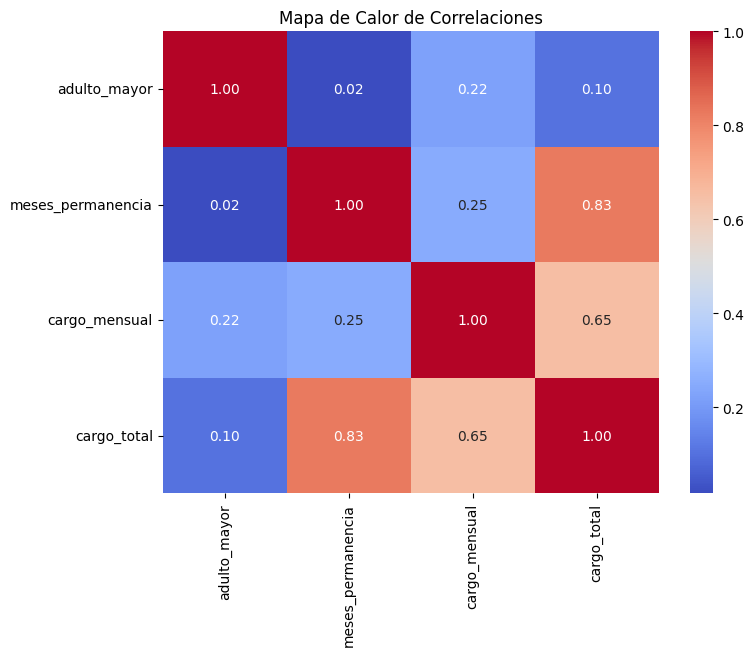

In [ ]:
# Filtramos solo las columnas numéricas
import matplotlib.pyplot as plt
import seaborn as sns
df_numerico = df.select_dtypes(include=['number'])

# Calculamos la correlación
matriz_correlacion = df_numerico.corr()

# La dibujamos en un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones')
plt.show()


In [ ]:
#Generamos reporte del perfilado de datos con ydata_profiling
!pip install ydata-profiling # Asegura que ydata-profiling esté instalado
import pandas as pd
import ydata_profiling as pp
from ydata_profiling import ProfileReport

reporte = pp.ProfileReport(df)
reporte.to_file(output_file='reporte.html')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.4 MB/s eta 0:00:00


/tmp/ipykernel_17735/590999080.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  import ydata_profiling as pp


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 20.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Visualizamos el reporte
reporte.to_notebook_iframe()

##Conclusiones y Tareas de Limpieza
Identificación de problemas y Conclusiones de la exploración:

**Tipos de datos:** El reporte inicial indica que TotalCharges es de tipo categórico (object) cuando lógicamente debería ser numérico. Esto ocurre porque los clientes nuevos (tenure = 0) tienen un espacio en blanco (" ") en lugar de un número.

**Valores Nulos:** A simple vista no hay nulos, pero al convertir TotalCharges a numérico, aparecerán valores perdidos (NaN) correspondientes a esos espacios en blanco.

**Distribuciones:** La variable objetivo (Churn) está desbalanceada. Hay muchos más clientes retenidos ("No") que cancelados ("Yes").

**Correlaciones:** Variables como tenure y TotalCharges tendrán una alta correlación positiva, ya que a más meses, mayor es el cobro total.

**Tareas específicas para la limpieza de datos**:

Conversión y manejo de nulos: Forzar la conversión de la columna TotalCharges a tipo numérico (float) y rellenar los valores nulos resultantes con 0 (ya que representan clientes con 0 meses de antigüedad que aún no han pagado su primera factura).

Eliminación de variables irrelevantes: Eliminar la columna customerID, ya que es un identificador único que no aporta valor analítico ni predictivo para entender el Churn.